# **Detecção de Fraudes em Transações Financeiras — Estudo de Caso (PyTorch) — v3.2 FINAL**
**Autor:** Carlos Ulisses Flores  
**Ambiente:** Google Colab (Python 3.x, PyTorch)  
**Licença:** Uso acadêmico/educacional.

## Resumo
Estudo de caso reprodutível de detecção de fraudes com dataset **ULB/Worldline**. Modelos: **MLP** (PyTorch),
**Autoencoder**, **Logistic Regression** e **Isolation Forest**. Métricas adequadas (ROC/PR/F1), *threshold tuning*,
explicabilidade (**Permutation Importance**), **stress test** (prior shift) e **PaySim** opcional.
Todos os artefatos são exportados para `exports/`.

In [1]:

# 0) Setup
!pip -q install --upgrade pip
!pip -q install --quiet tqdm

import os, sys, json, random, hashlib, platform, requests
from pathlib import Path
from datetime import datetime

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, classification_report
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest

def ensure_dir(path:Path) -> Path:
    path.mkdir(parents=True, exist_ok=True); return path

def sha256_of_file(path:Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1<<20), b""): h.update(chunk)
    return h.hexdigest()

def env_info():
    import numpy, pandas, sklearn, torch as th
    return {
        "python": sys.version.replace("\n"," "),
        "platform": platform.platform(),
        "numpy": numpy.__version__,
        "pandas": pandas.__version__,
        "sklearn": sklearn.__version__,
        "torch": th.__version__,
    }

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"

EXPORT = ensure_dir(Path("/content/exports"))
FIG    = ensure_dir(EXPORT/"figuras")
TAB    = ensure_dir(EXPORT/"tabelas")
META   = ensure_dir(EXPORT/"metadados")
DATA   = ensure_dir(Path("/content/data"))

print("ENV:", json.dumps(env_info(), indent=2))
print("Device:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 15.8 MB/s eta 0:00:00
ENV: {
  "python": "3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]",
  "platform": "Linux-6.1.123+-x86_64-with-glibc2.35",
  "numpy": "2.0.2",
  "pandas": "2.2.2",
  "sklearn": "1.6.1",
  "torch": "2.6.0+cu124"
}
Device: cpu


In [2]:

# 1) Dados (ULB/Worldline)
import requests

def download_to(path, url, chunk=1<<20):
    try:
        r = requests.get(url, stream=True, timeout=60)
        r.raise_for_status()
        total = int(r.headers.get("content-length", 0))
        with open(path, "wb") as f, tqdm(total=total, unit="B", unit_scale=True, desc=f"Baixando {path.name}") as bar:
            for b in r.iter_content(chunk_size=chunk):
                f.write(b); bar.update(len(b))
        return True
    except Exception as e:
        print("[WARN]", e); return False

CREDIT = DATA/"creditcard.csv"
for url in [
    "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv",
    "https://datahub.io/machine-learning/creditcard/r/creditcard.csv",
]:
    if CREDIT.exists(): break
    if download_to(CREDIT, url): break

meta_data = {
    "timestamp": datetime.utcnow().isoformat()+"Z",
    "creditcard": {
        "path": str(CREDIT),
        "exists": CREDIT.exists(),
        "sha256": sha256_of_file(CREDIT) if CREDIT.exists() else None
    },
    "env": env_info()
}
print(json.dumps(meta_data, indent=2))
assert CREDIT.exists(), "creditcard.csv não encontrado."


Baixando creditcard.csv: 100%|██████████| 151M/151M [00:00<00:00, 156MB/s]


{
  "timestamp": "2025-08-16T13:59:23.556710Z",
  "creditcard": {
    "path": "/content/data/creditcard.csv",
    "exists": true,
    "sha256": "76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89"
  },
  "env": {
    "python": "3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]",
    "platform": "Linux-6.1.123+-x86_64-with-glibc2.35",
    "numpy": "2.0.2",
    "pandas": "2.2.2",
    "sklearn": "1.6.1",
    "torch": "2.6.0+cu124"
  }
}


Dimensões: (284807, 31)
Proporção de classes:
 Class
0    0.998273
1    0.001727
Name: proporcao, dtype: float64


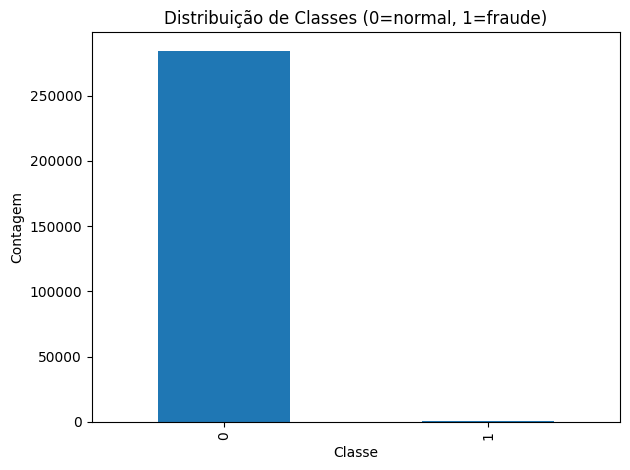

Shapes: torch.Size([199364, 30]) torch.Size([42721, 30]) torch.Size([42722, 30]) | device: cpu


In [3]:

# 2) EDA / split / normalização
df = pd.read_csv(CREDIT)
y  = df["Class"].astype(int).values
X  = df.drop(columns=["Class"])

print("Dimensões:", df.shape)
print("Proporção de classes:\n", df["Class"].value_counts(normalize=True).rename("proporcao"))

plt.figure()
df["Class"].value_counts().plot(kind="bar")
plt.title("Distribuição de Classes (0=normal, 1=fraude)")
plt.xlabel("Classe"); plt.ylabel("Contagem")
plt.tight_layout(); plt.savefig(FIG/"distribuicao_classes.png", dpi=120); plt.show()

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, random_state=SEED, stratify=y)
X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp)

scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr); X_va_s = scaler.transform(X_va); X_te_s = scaler.transform(X_te)

Xtr_t = torch.tensor(X_tr_s, dtype=torch.float32)
ytr_t = torch.tensor(y_tr,   dtype=torch.float32).unsqueeze(1)
Xva_t = torch.tensor(X_va_s, dtype=torch.float32)
yva_t = torch.tensor(y_va,   dtype=torch.float32).unsqueeze(1)
Xte_t = torch.tensor(X_te_s, dtype=torch.float32)
yte_t = torch.tensor(y_te,   dtype=torch.float32).unsqueeze(1)

print("Shapes:", Xtr_t.shape, Xva_t.shape, Xte_t.shape, "| device:", device)


In [4]:

# 3) MLP supervisionado (PyTorch)
class MLP(nn.Module):
    def __init__(self, in_features:int, hidden=(64,32), p_drop=0.2):
        super().__init__()
        layers=[]; prev=in_features
        for h in hidden:
            layers += [nn.Linear(prev,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(p_drop)]
            prev=h
        layers += [nn.Linear(prev,1)]
        self.net = nn.Sequential(*layers)
    def forward(self,x): return self.net(x)

def train_mlp(Xtr_t, ytr_t, Xva_t, yva_t, epochs=40, batch_size=512, lr=1e-3):
    model=MLP(Xtr_t.shape[1]).to(device)
    pos=(ytr_t==1).sum().item(); neg=(ytr_t==0).sum().item()
    pos_weight=torch.tensor([neg/max(pos,1)], dtype=torch.float32, device=device)
    crit=nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    opt=torch.optim.Adam(model.parameters(), lr=lr)

    def pass_epoch(X_t, y_t, train:bool):
        ds=TensorDataset(X_t, y_t); dl=DataLoader(ds, batch_size=batch_size, shuffle=train)
        tot=0.0; probs=[]; gts=[]
        model.train() if train else model.eval()
        for xb,yb in dl:
            xb=xb.to(device); yb=yb.to(device)
            with torch.set_grad_enabled(train):
                logits=model(xb); loss=crit(logits,yb)
                if train: opt.zero_grad(); loss.backward(); opt.step()
            tot+=loss.item()*xb.size(0)
            probs.append(torch.sigmoid(logits).detach().cpu().numpy()); gts.append(yb.cpu().numpy())
        return tot/len(ds), np.vstack(gts).ravel().astype(int), np.vstack(probs).ravel()

    best=-1; state=None
    for ep in range(1,epochs+1):
        tr,_,_ = pass_epoch(Xtr_t, ytr_t, True)
        va,yv,pv = pass_epoch(Xva_t, yva_t, False)
        f1 = f1_score(yv, (pv>=0.5).astype(int), zero_division=0)
        if f1>best: best=f1; state=model.state_dict().copy()
        if ep%5==0 or ep==1: print(f"[Ep {ep:03d}] loss_tr={tr:.4f} loss_val={va:.4f} F1@0.5_val={f1:.4f}")
    model.load_state_dict(state); return model

def thresholds_from_probs(y_true, probs):
    ths = np.linspace(0.01,0.99,99)
    f1s  = [f1_score(y_true,(probs>=t).astype(int), zero_division=0) for t in ths]
    fb2s = [fbeta_score(y_true,(probs>=t).astype(int), beta=2, zero_division=0) for t in ths]
    return float(ths[int(np.argmax(f1s))]), float(ths[int(np.argmax(fb2s))])

def eval_probs(y_true, probs, thr, name, cm_rows:list):
    yhat=(probs>=thr).astype(int); y_true=y_true.astype(int)
    acc=accuracy_score(y_true,yhat); prec=precision_score(y_true,yhat,zero_division=0)
    rec=recall_score(y_true,yhat,zero_division=0); f1=f1_score(y_true,yhat,zero_division=0)
    print(f"\nRelatório ({name}):\n", classification_report(y_true,yhat,digits=4))
    tn, fp, fn, tp = confusion_matrix(y_true,yhat).ravel()
    cm_rows.append({"model":name, "tn":tn, "fp":fp, "fn":fn, "tp":tp})
    return {"model":name,"accuracy":acc,"precision":prec,"recall":rec,"f1":f1}

mlp = train_mlp(Xtr_t, ytr_t, Xva_t, yva_t)
with torch.no_grad():
    p_va = torch.sigmoid(mlp(Xva_t.to(device))).cpu().numpy().ravel()
    p_te = torch.sigmoid(mlp(Xte_t.to(device))).cpu().numpy().ravel()
t_f1, t_fb2 = thresholds_from_probs(y_va, p_va)
print(f"Thresholds MLP: t_F1={t_f1:.2f} | t_Fb2={t_fb2:.2f}")

cm_rows=[]; res_rows=[]
res_rows += [eval_probs(y_va, p_va, 0.5, "MLP_val@0.5", cm_rows),
             eval_probs(y_te, p_te, 0.5, "MLP_test@0.5", cm_rows),
             eval_probs(y_va, p_va, t_f1, f"MLP_val@{t_f1:.2f}", cm_rows),
             eval_probs(y_te, p_te, t_f1, f"MLP_test@{t_f1:.2f}", cm_rows),
             eval_probs(y_va, p_va, t_fb2, f"MLP_val@Fb2={t_fb2:.2f}", cm_rows),
             eval_probs(y_te, p_te, t_fb2, f"MLP_test@Fb2={t_fb2:.2f}", cm_rows)]


[Ep 001] loss_tr=0.5587 loss_val=0.4320 F1@0.5_val=0.0868
[Ep 005] loss_tr=0.1948 loss_val=0.4298 F1@0.5_val=0.1918
[Ep 010] loss_tr=0.1610 loss_val=0.5181 F1@0.5_val=0.1201
[Ep 015] loss_tr=0.1555 loss_val=0.5117 F1@0.5_val=0.1013
[Ep 020] loss_tr=0.0957 loss_val=0.7170 F1@0.5_val=0.1857
[Ep 025] loss_tr=0.0998 loss_val=0.8381 F1@0.5_val=0.1481
[Ep 030] loss_tr=0.1117 loss_val=1.0260 F1@0.5_val=0.1649
[Ep 035] loss_tr=0.0726 loss_val=1.0788 F1@0.5_val=0.1754
[Ep 040] loss_tr=0.0651 loss_val=1.3490 F1@0.5_val=0.2109
Thresholds MLP: t_F1=0.99 | t_Fb2=0.99

Relatório (MLP_val@0.5):
               precision    recall  f1-score   support

           0     0.9997    0.9894    0.9945     42647
           1     0.1206    0.8378    0.2109        74

    accuracy                         0.9891     42721
   macro avg     0.5602    0.9136    0.6027     42721
weighted avg     0.9982    0.9891    0.9932     42721


Relatório (MLP_test@0.5):
               precision    recall  f1-score   support

  

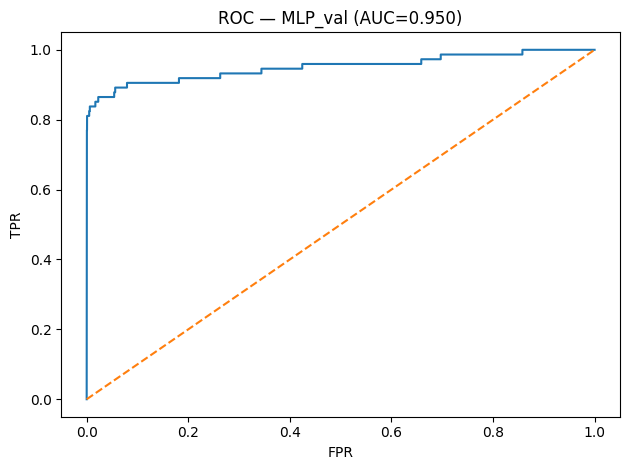

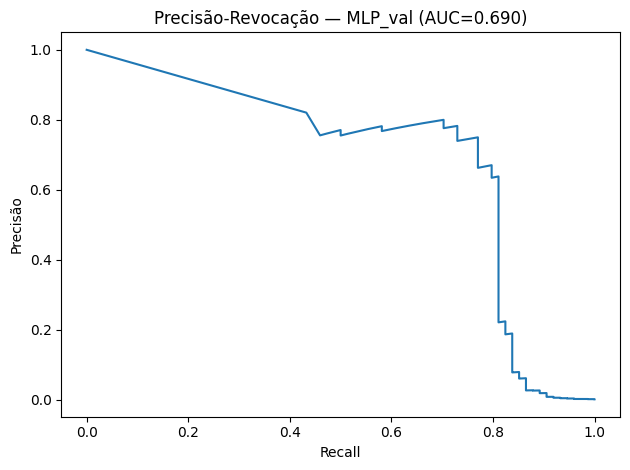

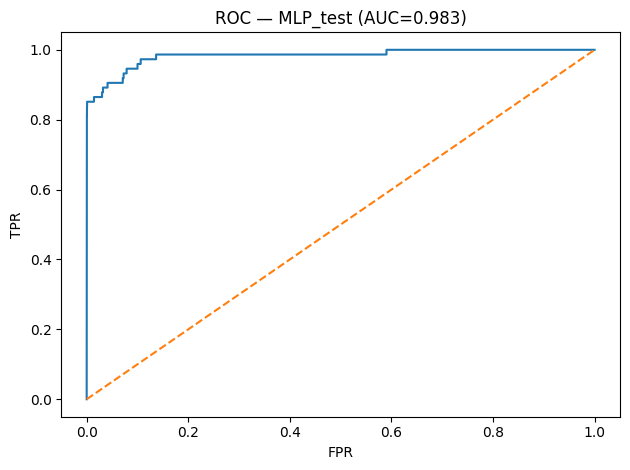

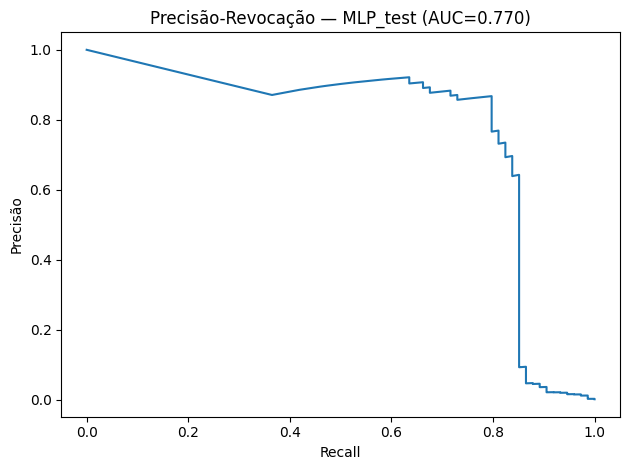

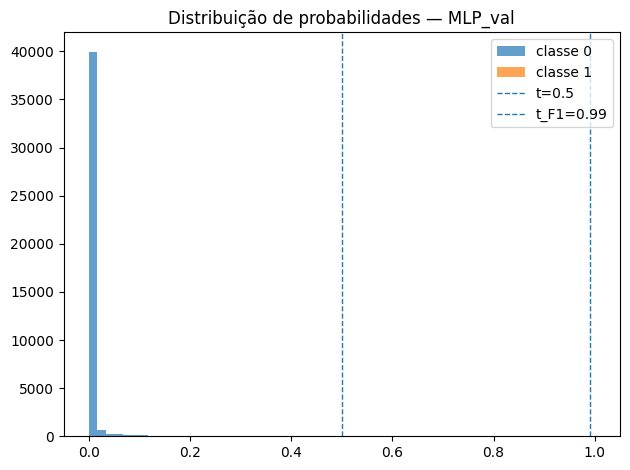

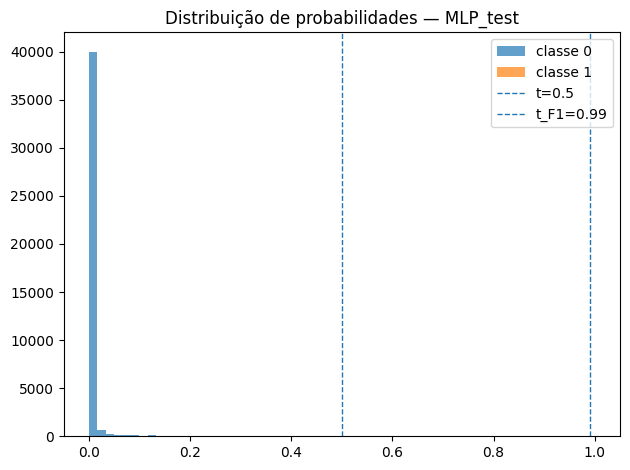

In [5]:

# 4) ROC/PR e histogramas
def plot_roc_pr(y_true, probs, prefix):
    fpr,tpr,_=roc_curve(y_true, probs); roc_auc=auc(fpr,tpr)
    plt.figure(); plt.plot(fpr,tpr); plt.plot([0,1],[0,1],'--')
    plt.title(f"ROC — {prefix} (AUC={roc_auc:.3f})"); plt.xlabel("FPR"); plt.ylabel("TPR")
    plt.tight_layout(); plt.savefig(FIG/f"roc_{prefix}.png", dpi=120); plt.show()
    pr_p,pr_r,_=precision_recall_curve(y_true, probs); pr_auc=auc(pr_r,pr_p)
    plt.figure(); plt.plot(pr_r, pr_p)
    plt.title(f"Precisão-Revocação — {prefix} (AUC={pr_auc:.3f})"); plt.xlabel("Recall"); plt.ylabel("Precisão")
    plt.tight_layout(); plt.savefig(FIG/f"pr_{prefix}.png", dpi=120); plt.show()

def plot_prob_hist(y_true, probs, prefix, t_f1, t05=0.5):
    plt.figure()
    plt.hist(probs[y_true==0], bins=60, alpha=0.7, label="classe 0")
    plt.hist(probs[y_true==1], bins=60, alpha=0.7, label="classe 1")
    plt.axvline(t05, linestyle='--', linewidth=1, label='t=0.5')
    plt.axvline(t_f1, linestyle='--', linewidth=1, label=f't_F1={t_f1:.2f}')
    plt.legend(); plt.title(f"Distribuição de probabilidades — {prefix}")
    plt.tight_layout(); plt.savefig(FIG/f"prob_hist_{prefix}.png", dpi=120); plt.show()

plot_roc_pr(y_va, p_va, "MLP_val"); plot_roc_pr(y_te, p_te, "MLP_test")
plot_prob_hist(y_va, p_va, "MLP_val", t_f1); plot_prob_hist(y_te, p_te, "MLP_test", t_f1)


In [6]:

# 5) Autoencoder (não supervisionado)
class AE(nn.Module):
    def __init__(self, in_features:int, bottleneck:int=8):
        super().__init__()
        self.encoder=nn.Sequential(nn.Linear(in_features,64), nn.ReLU(),
                                   nn.Linear(64,32), nn.ReLU(), nn.Linear(32,bottleneck))
        self.decoder=nn.Sequential(nn.Linear(bottleneck,32), nn.ReLU(),
                                   nn.Linear(32,64), nn.ReLU(), nn.Linear(64,in_features))
    def forward(self,x): z=self.encoder(x); return self.decoder(z)

def train_ae(X_norm, epochs=40, batch=512, lr=1e-3):
    model=AE(X_norm.shape[1]).to(device)
    opt=torch.optim.Adam(model.parameters(), lr=lr); crit=nn.MSELoss()
    ds=TensorDataset(X_norm); dl=DataLoader(ds, batch_size=batch, shuffle=True)
    for ep in range(1,epochs+1):
        model.train(); tot=0.0
        for (xb,) in dl:
            xb=xb.to(device); rec=model(xb); loss=crit(rec,xb)
            opt.zero_grad(); loss.backward(); opt.step(); tot+=loss.item()*xb.size(0)
        if ep%5==0 or ep==1: print(f"[AE Ep {ep:03d}] loss_tr={tot/len(ds):.6f}")
    return model

mask0=(ytr_t.squeeze()==0); Xtr_norm=Xtr_t[mask0]
ae = train_ae(Xtr_norm, epochs=40)

with torch.no_grad():
    rec_va=ae(Xva_t.to(device)).cpu().numpy(); err_va=((rec_va - X_va_s)**2).mean(axis=1)
    rec_te=ae(Xte_t.to(device)).cpu().numpy(); err_te=((rec_te - X_te_s)**2).mean(axis=1)

percs=np.linspace(50,99.9,80)
best=-1; th_f1=None
for p in percs:
    t=np.percentile(err_va,p); yhat=(err_va>=t).astype(int)
    s=f1_score(y_va,yhat,zero_division=0)
    if s>best: best, th_f1 = s, t

def eval_ae(err, y_true, th, name, cm_rows:list):
    yhat=(err>=th).astype(int); y_true=y_true.astype(int)
    acc=accuracy_score(y_true,yhat); prec=precision_score(y_true,yhat,zero_division=0)
    rec=recall_score(y_true,yhat,zero_division=0); f1=f1_score(y_true,yhat,zero_division=0)
    print(f"\nRelatório ({name}):\n", classification_report(y_true,yhat,digits=4))
    tn, fp, fn, tp = confusion_matrix(y_true,yhat).ravel()
    cm_rows.append({"model":name, "tn":tn, "fp":fp, "fn":fn, "tp":tp})
    return {"model":name,"accuracy":acc,"precision":prec,"recall":rec,"f1":f1}

res_rows += [eval_ae(err_va, y_va, th_f1, "AE_val@F1", cm_rows),
             eval_ae(err_te, y_te, th_f1, "AE_test@F1", cm_rows)]


[AE Ep 001] loss_tr=0.633064
[AE Ep 005] loss_tr=0.254666
[AE Ep 010] loss_tr=0.205559
[AE Ep 015] loss_tr=0.180014
[AE Ep 020] loss_tr=0.165385
[AE Ep 025] loss_tr=0.155077
[AE Ep 030] loss_tr=0.144468
[AE Ep 035] loss_tr=0.135633
[AE Ep 040] loss_tr=0.129814

Relatório (AE_val@F1):
               precision    recall  f1-score   support

           0     0.9993    0.9937    0.9965     42647
           1     0.1406    0.5946    0.2274        74

    accuracy                         0.9930     42721
   macro avg     0.5699    0.7941    0.6119     42721
weighted avg     0.9978    0.9930    0.9952     42721


Relatório (AE_test@F1):
               precision    recall  f1-score   support

           0     0.9993    0.9930    0.9961     42648
           1     0.1304    0.6081    0.2148        74

    accuracy                         0.9923     42722
   macro avg     0.5649    0.8005    0.6055     42722
weighted avg     0.9978    0.9923    0.9948     42722



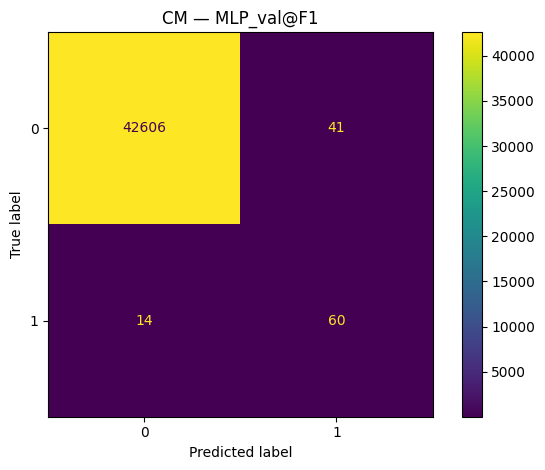

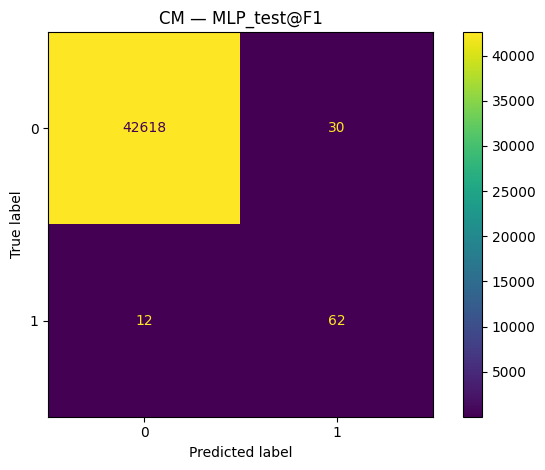

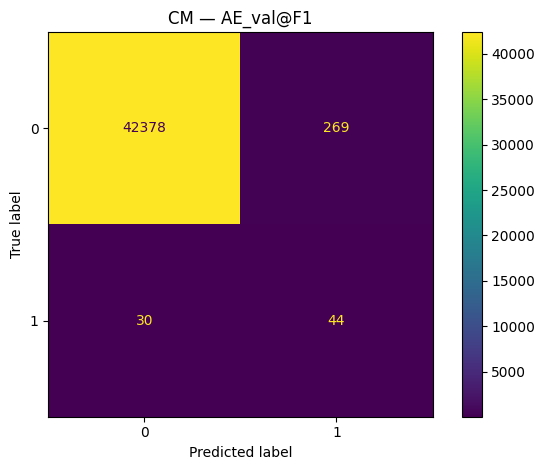

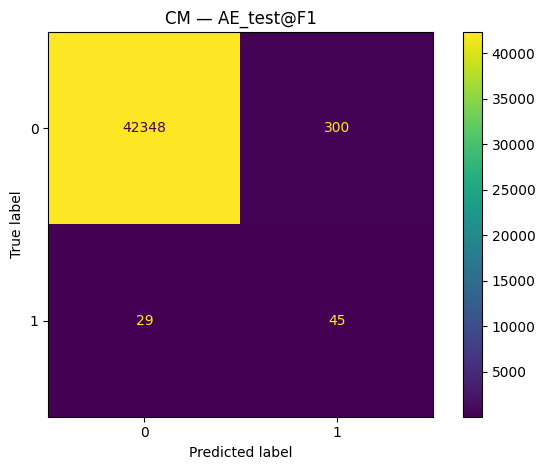

In [7]:

# 6) Confusion matrices + CSV
def cm_plot(y_true, yhat, title, fname):
    cm=confusion_matrix(y_true,yhat); disp=ConfusionMatrixDisplay(cm, display_labels=[0,1])
    disp.plot(values_format="d"); plt.title(title); plt.tight_layout(); plt.savefig(FIG/fname, dpi=120); plt.show()

yhat_va_mlp=(p_va>=t_f1).astype(int); yhat_te_mlp=(p_te>=t_f1).astype(int)
cm_plot(y_va, yhat_va_mlp, "CM — MLP_val@F1", "cm_mlp_val_f1.png")
cm_plot(y_te, yhat_te_mlp, "CM — MLP_test@F1", "cm_mlp_test_f1.png")

yhat_va_ae=(err_va>=th_f1).astype(int); yhat_te_ae=(err_te>=th_f1).astype(int)
cm_plot(y_va, yhat_va_ae, "CM — AE_val@F1", "cm_ae_val_f1.png")
cm_plot(y_te, yhat_te_ae, "CM — AE_test@F1", "cm_ae_test_f1.png")

pd.DataFrame(cm_rows).to_csv(TAB/"confusion_matrices.csv", index=False)


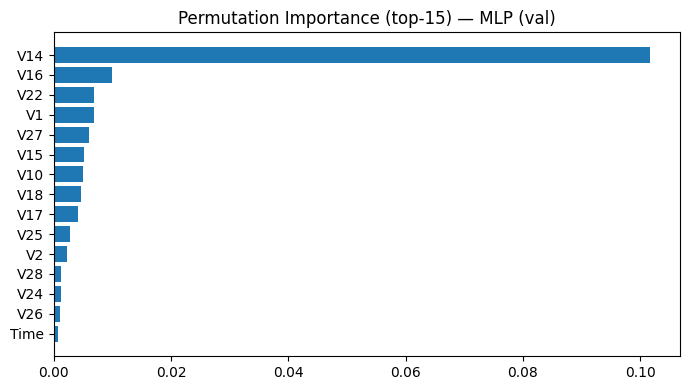

In [8]:

# 7) Permutation Importance (MLP)
class SkWrapper:
    def __init__(self, mdl, thr): self.mdl=mdl; self.thr=thr
    def fit(self, X, y=None): return self
    def predict(self, X):
        Xt=torch.tensor(X, dtype=torch.float32, device=device)
        with torch.no_grad(): probs=torch.sigmoid(self.mdl(Xt)).cpu().numpy().ravel()
        return (probs>=self.thr).astype(int)

pi = permutation_importance(SkWrapper(mlp, t_f1), X_va_s, y_va, scoring="f1", n_repeats=5, random_state=42)
imp_df = pd.DataFrame({"feature": df.drop(columns=["Class"]).columns, "importance": pi.importances_mean}).sort_values("importance", ascending=False)
imp_df.to_csv(TAB/"permutation_importance_mlp_val.csv", index=False)
plt.figure(figsize=(7,4)); plt.barh(imp_df["feature"].head(15)[::-1], imp_df["importance"].head(15)[::-1])
plt.title("Permutation Importance (top-15) — MLP (val)")
plt.tight_layout(); plt.savefig(FIG/"permutation_importance_mlp_val.png", dpi=120); plt.show()


In [9]:

# 8) Baselines: LR e Isolation Forest
lr = LogisticRegression(max_iter=200, class_weight="balanced", solver="liblinear")
lr.fit(X_tr_s, y_tr)
pr_va_lr = lr.predict_proba(X_va_s)[:,1]; pr_te_lr = lr.predict_proba(X_te_s)[:,1]
t_f1_lr, t_fb2_lr = thresholds_from_probs(y_va, pr_va_lr)
res_rows += [eval_probs(y_va, pr_va_lr, t_f1_lr, f"LR_val@{t_f1_lr:.2f}", cm_rows),
             eval_probs(y_te, pr_te_lr, t_f1_lr, f"LR_test@{t_f1_lr:.2f}", cm_rows)]

iso = IsolationForest(n_estimators=200, contamination="auto", random_state=42)
iso.fit(X_tr_s[y_tr==0])
sc_va = -iso.score_samples(X_va_s); sc_te = -iso.score_samples(X_te_s)
best=-1; th_iso=None
for p in np.linspace(50,99.9,80):
    t=np.percentile(sc_va,p); yhat=(sc_va>=t).astype(int)
    s=f1_score(y_va,yhat,zero_division=0)
    if s>best: best, th_iso = s, t
res_rows += [eval_probs(y_va, sc_va, th_iso, "IF_val@F1", cm_rows),
             eval_probs(y_te, sc_te, th_iso, "IF_test@F1", cm_rows)]



Relatório (LR_val@0.99):
               precision    recall  f1-score   support

           0     0.9996    0.9989    0.9993     42647
           1     0.5619    0.7973    0.6592        74

    accuracy                         0.9986     42721
   macro avg     0.7808    0.8981    0.8293     42721
weighted avg     0.9989    0.9986    0.9987     42721


Relatório (LR_test@0.99):
               precision    recall  f1-score   support

           0     0.9997    0.9993    0.9995     42648
           1     0.6742    0.8108    0.7362        74

    accuracy                         0.9990     42722
   macro avg     0.8369    0.9051    0.8678     42722
weighted avg     0.9991    0.9990    0.9990     42722


Relatório (IF_val@F1):
               precision    recall  f1-score   support

           0     0.9991    0.9935    0.9963     42647
           1     0.1118    0.4730    0.1809        74

    accuracy                         0.9926     42721
   macro avg     0.5555    0.7332    0.5886     

In [10]:

# 9) Stress test (prior shift)
def prior_shift_eval(scores, y_true, thr, ratio, name):
    y_np=y_true.astype(int); n=len(y_np)
    idx_pos=np.where(y_np==1)[0]; idx_neg=np.where(y_np==0)[0]
    n_pos=max(1,int(n*ratio)); n_neg=n-n_pos
    sel=np.concatenate([np.random.choice(idx_pos, size=min(n_pos,len(idx_pos)), replace=len(idx_pos)<n_pos),
                        np.random.choice(idx_neg, size=min(n_neg,len(idx_neg)), replace=len(idx_neg)<n_neg)])
    np.random.shuffle(sel)
    yhat=(scores[sel]>=thr).astype(int); ysel=y_np[sel]
    return {"model":name, "accuracy":accuracy_score(ysel,yhat),
            "precision":precision_score(ysel,yhat,zero_division=0),
            "recall":recall_score(ysel,yhat,zero_division=0),
            "f1":f1_score(ysel,yhat,zero_division=0),
            "pos_ratio":ratio}

rows=[]
for r in [0.01,0.05,0.10,0.20]:
    rows.append(prior_shift_eval(p_te,   y_te, t_f1,    r, f"MLP_prior_{r:.2f}@F1"))
    rows.append(prior_shift_eval(pr_te_lr, y_te, t_f1_lr, r, f"LR_prior_{r:.2f}@F1"))
    rows.append(prior_shift_eval(sc_te,  y_te, th_iso,  r, f"IF_prior_{r:.2f}@F1"))
stress = pd.DataFrame(rows); stress.to_csv(TAB/"stress_prior_shift_v3p2.csv", index=False); print(stress)


                model  accuracy  precision    recall        f1  pos_ratio
0   MLP_prior_0.01@F1  0.999009   0.673913  0.837838  0.746988       0.01
1    LR_prior_0.01@F1  0.998820   0.646341  0.716216  0.679487       0.01
2    IF_prior_0.01@F1  0.992754   0.120521  0.500000  0.194226       0.01
3   MLP_prior_0.05@F1  0.998967   0.677778  0.824324  0.743902       0.05
4    LR_prior_0.05@F1  0.998967   0.690476  0.783784  0.734177       0.05
5    IF_prior_0.05@F1  0.992745   0.122867  0.486486  0.196185       0.05
6   MLP_prior_0.10@F1  0.998806   0.662791  0.770270  0.712500       0.10
7    LR_prior_0.10@F1  0.999066   0.711111  0.864865  0.780488       0.10
8    IF_prior_0.10@F1  0.992628   0.122302  0.459459  0.193182       0.10
9   MLP_prior_0.20@F1  0.998774   0.690476  0.783784  0.734177       0.20
10   LR_prior_0.20@F1  0.998891   0.719512  0.797297  0.756410       0.20
11   IF_prior_0.20@F1  0.992526   0.117647  0.378378  0.179487       0.20


## 10) PaySim (opcional)
- Coloque o CSV em `/content/data/` com nome `PS_20174392719_1491204439457_log.csv` ou `paysim.csv`.
- Executa *one-hot*, normalização, LR e MLP simples; exporta resultados.

In [11]:

PAYSIM = None
for nm in ["PS_20174392719_1491204439457_log.csv", "paysim.csv"]:
    pth = Path("/content/data")/nm
    if pth.exists(): PAYSIM = pth; break

if PAYSIM is None:
    print("[INFO] PaySim não encontrado.")
else:
    ps = pd.read_csv(PAYSIM).rename(columns=str.strip)
    yps = ps["isFraud"].astype(int).values
    Xps = ps[["type","amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest"]].copy()

    ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    Xt_c = ohe.fit_transform(Xps[["type"]])
    Xps_n = Xps.drop(columns=["type"]).values.astype(float)
    Xps_all = np.hstack([Xt_c, Xps_n])

    Xps_tr, Xps_tmp, yps_tr, yps_tmp = train_test_split(Xps_all, yps, test_size=0.30, stratify=yps, random_state=42)
    Xps_va, Xps_te, yps_va, yps_te = train_test_split(Xps_tmp, yps_tmp, test_size=0.50, stratify=yps_tmp, random_state=42)
    sc2 = StandardScaler()
    Xps_trs = sc2.fit_transform(Xps_tr); Xps_vas = sc2.transform(Xps_va); Xps_tes = sc2.transform(Xps_te)

    rows_ps = []; cm_ps = []

    lr2 = LogisticRegression(max_iter=300, class_weight="balanced", solver="liblinear")
    lr2.fit(Xps_trs, yps_tr)
    pr_va2 = lr2.predict_proba(Xps_vas)[:,1]; pr_te2 = lr2.predict_proba(Xps_tes)[:,1]
    t2,_ = thresholds_from_probs(yps_va, pr_va2)
    rows_ps += [eval_probs(yps_va, pr_va2, t2, "PS_LR_val@F1", cm_ps),
                eval_probs(yps_te, pr_te2, t2, "PS_LR_test@F1", cm_ps)]

    Xps_trt = torch.tensor(Xps_trs, dtype=torch.float32); yps_trt = torch.tensor(yps_tr, dtype=torch.float32).unsqueeze(1)
    Xps_vat = torch.tensor(Xps_vas, dtype=torch.float32); yps_vat = torch.tensor(yps_va, dtype=torch.float32).unsqueeze(1)
    Xps_tet = torch.tensor(Xps_tes, dtype=torch.float32); yps_tet = torch.tensor(yps_te, dtype=torch.float32).unsqueeze(1)
    mlpps = train_mlp(Xps_trt, yps_trt, Xps_vat, yps_vat, epochs=20)
    with torch.no_grad():
        pva2 = torch.sigmoid(mlpps(Xps_vat)).cpu().numpy().ravel()
        pte2 = torch.sigmoid(mlpps(Xps_tet)).cpu().numpy().ravel()
    tps,_ = thresholds_from_probs(yps_va, pva2)
    rows_ps += [eval_probs(yps_va, pva2, tps, "PS_MLP_val@F1", cm_ps),
                eval_probs(yps_te, pte2, tps, "PS_MLP_test@F1", cm_ps)]

    pd.DataFrame(rows_ps).to_csv(TAB/"paysim_resultados.csv", index=False)
    pd.DataFrame(cm_ps).to_csv(TAB/"paysim_confusion_matrices.csv", index=False)
    print(pd.read_csv(TAB/"paysim_resultados.csv"))


[INFO] PaySim não encontrado.


In [12]:

# 11) Tabelas finais e sumário
final = pd.DataFrame(res_rows)
final.to_csv(TAB/"comparacao_final_v3p2.csv", index=False)
print(final)

summary = {
    "data_meta": {"creditcard": {"path": "/content/data/creditcard.csv", "sha256": sha256_of_file(Path('/content/data/creditcard.csv'))}},
    "env": env_info(), "seed": 42, "exports_dir": "/content/exports",
    "metrics": json.loads(final.to_json(orient="records"))
}
with open(META/"sumario_final_v3p2.json","w") as f: json.dump(summary,f,indent=2)
print(json.dumps(summary, indent=2))

print("\nArquivos em /content/exports/:")
for root,dirs,files in os.walk("/content/exports/"):
    for f in files: print(os.path.join(root,f))


                model  accuracy  precision    recall        f1
0         MLP_val@0.5  0.989139   0.120623  0.837838  0.210884
1        MLP_test@0.5  0.988928   0.120000  0.851351  0.210351
2        MLP_val@0.99  0.998713   0.594059  0.810811  0.685714
3       MLP_test@0.99  0.999017   0.673913  0.837838  0.746988
4    MLP_val@Fb2=0.99  0.998713   0.594059  0.810811  0.685714
5   MLP_test@Fb2=0.99  0.999017   0.673913  0.837838  0.746988
6           AE_val@F1  0.993001   0.140575  0.594595  0.227390
7          AE_test@F1  0.992299   0.130435  0.608108  0.214797
8         LR_val@0.99  0.998572   0.561905  0.797297  0.659218
9        LR_test@0.99  0.998993   0.674157  0.810811  0.736196
10          IF_val@F1  0.992580   0.111821  0.472973  0.180879
11         IF_test@F1  0.992720   0.111475  0.459459  0.179420
{
  "data_meta": {
    "creditcard": {
      "path": "/content/data/creditcard.csv",
      "sha256": "76274b691b16a6c49d3f159c883398e03ccd6d1ee12d9d8ee38f4b4b98551a89"
    }
  },
  

## 12) Replicação e notas finais
- Executar todas as células em ordem (GPU opcional).
- Os artefatos são salvos em `exports/`.
- *Thresholds* são ajustados por F1 e Fβ=2 na validação.
- Ajuste o *threshold* conforme custos de erro do problema real (FN vs FP).